This is a parallel notebook to _process_MC.py_ script intended for testing the different steps involved in the data processing.

In [1]:
import sys
sys.path.append('/lhome/ific/c/ccortesp/Analysis')

from libs import crudo

from datetime import datetime
import glob
from invisible_cities.reco.corrections import apply_all_correction
from invisible_cities.reco.corrections import read_maps
from invisible_cities.types.symbols    import NormStrategy
from joblib import delayed, Parallel
import matplotlib.pyplot as plt
from matplotlib.offsetbox import (OffsetImage, AnnotationBbox)
import numpy as np
import os
import pandas as pd
from pathlib import Path
from PIL import Image
import scipy

# Styling Plot
crudo.pt.ccortesp_plot_style()
PRELIM_LOGO = np.asarray(Image.open('/lhome/ific/c/ccortesp/Analysis/images/next_logo_preliminary.png'))

%matplotlib inline
%load_ext autoreload
%autoreload 2

## Configuration

In [2]:
# ----- Processing Details
PROCESS_TYPE = 'radiogenics_lpr'      # Choices: 'radiogenics_hpr', 'radiogenics_lpr', 'bb2nu_hpr', 'bb2nu_lpr', 'bb0nu_hpr', 'bb0nu_lpr'
ISOTOPE = 'K40'               # Choices: 'Bi214', 'Co60', 'K40', 'Tl208', 'Tl214', 'Xe136'

In [3]:
DATE = datetime.now().strftime('%d%m%Y')    # It helps to keep track of when the files were processed

# DIRECTORIES
OUTPUT_DIR  = '/lustre/ific.uv.es/prj/gl/neutrinos/users/ccortesp/NEXT-100/Backgrounds/h5/mc/'
SUMMARY_DIR = '/lhome/ific/c/ccortesp/Analysis/NEXT-100/Backgrounds/txt/summaries/'

# KEYS
MC_CONFIG_KEY = '/MC/configuration'
TRUE_INFO_KEY = '/MC/particles'
DORO_KEY = '/DST/Events'
SOPH_KEY = '/RECO/Events'

# COLUMNS TO USE
DORO_COLUMNS = ['event', 'time', 'nS1', 'nS2', 'S1w', 'S1h', 'S1e', 'S1t', 'S2w', 'S2h', 'S2e', 'S2q', 'S2t', 'DT', 'X', 'Y', 'Z']
SOPH_COLUMNS = ['event', 'time', 'npeak', 'Xpeak','X', 'Y', 'Z', 'Q', 'Ec']
FINAL_SOPH_COLUMNS = ['event', 'time', 'npeak', 'X', 'Y', 'Z', 'E_hit_mev', 'cluster']

EVENT_LEVEL_COLS = ['nS1', 'nS2', 'isotope', 'volume', 'double_e', 'old_n_hits']

# CUTFLOW
CUT_NAMES = ['Generated', 'Interacting', 'Saved', 'Reconstructed', 'Strong_S2', 'S1_Cut', 'Clean_Events']

# ---------------------
# PROCESSING PARAMETERS
# ---------------------
V_DRIFT = 0.865     # Drift velocity in [mm/μs]

# --- S1 Signal Cuts ---
# Po-like events are filtered using: S1h >= m * S1e + b
M_NOPOLIKE = 0.17
B_NOPOLIKE = -56

# --- S1e Correction ---
# Values from Radon analysis: S1e = m * DT + b
DT_CATH = 1350               # Cathode temporal position in [μs]
CV_FIT  = [0.57, 796.53]     # Fit values from S1e vs DT plot

# --- Hits Clusterizer ---
CLUSTERING_PARAMS = dict(eps = 3, min_samples = 5, scale_xy = 15.55, scale_z = 4.0)
CLUSTER_FUNCTION = crudo.tf.hits_clusterizer(CLUSTERING_PARAMS)

# --------------------------------
# ALPHA/ELECTRON DISCRIMINATION
# --------------------------------
SIZE_THRESHOLD = 2e3            # in [# of hits]
S1_ENERGY_THRESHOLD = 900      # in [PE]

# -------------------
# DETECTOR REGIONS
# -------------------
# Geometric boundaries for event classification.
Z_LOW = 40          # in [mm]
Z_UP  = 1147        # in [mm]
R_UP  = 451.65      # in [mm]

# --- Trigger 2 Efficiency Cut ---
# Events with event-level energy below this are removed to account for trigger efficiency
TRG2_THRESHOLD = 0.5   # in [MeV]

In [4]:
print("\n----- Processing Configuration -----")
print(f"Date: {DATE}")
print(f"Process Type: {PROCESS_TYPE}")
print(f"Isotopes: {ISOTOPE}")
print("------------------------------------")

# Outputs
output_filename = 'processed_mc_' + PROCESS_TYPE + '_'
if ISOTOPE != 'Xe136':  output_filename += ISOTOPE + '_' + DATE + '.h5'
output_filename += DATE + '.h5'
OUTPUT_FILEPATH = os.path.join(OUTPUT_DIR, output_filename)

summary_filename = 'summary_mc_' + PROCESS_TYPE + '_processed.csv'
SUMMARY_PATH = os.path.join(SUMMARY_DIR, summary_filename)

# Files to process
MC_DIR = '/lustre/ific.uv.es/prj/gl/neutrinos/NEXT/MC/NEXT100/'
MC_PATHS = []

if PROCESS_TYPE == 'radiogenics_hpr': MC_DIR += 'Radiogenics/HPR/IC_v2.3.1/NEXUS_v7_10_01/'
if PROCESS_TYPE == 'radiogenics_lpr': MC_DIR += 'Radiogenics/LPR/IC_v2.3.1/NEXUS_v7_09_00/'
if PROCESS_TYPE == 'bb2nu_hpr':       MC_DIR += 'bb2nu/HPR/IC_v2.3.1/NEXUS_v7_10_01/bb2nu/'
if PROCESS_TYPE == 'bb0nu_hpr':       MC_DIR += 'bb0nu/HPR/IC_v2.3.1/NEXUS_v7_10_01/bb0nu/'

if ISOTOPE != 'Xe136':  MC_DIR += ISOTOPE + '/'
# Get all subfolders in MC_DIR
VOLUMES = [folder for folder in os.listdir(MC_DIR) if os.path.isdir(os.path.join(MC_DIR, folder))]
for volume in sorted(VOLUMES):
    # Get all sophronia files in the volume subfolder
    sophronia_files = sorted(glob.glob(os.path.join(MC_DIR, volume, 'sophronia', '*.sophronia.h5')))
    # print(f"  Found {len(sophronia_files)} sophronia files in {volume}")
    if sophronia_files:
        MC_PATHS.extend(sophronia_files)
    else:
        print(f"  {ISOTOPE}/{volume}: No Sophronia files found")
MC_PATHS = sorted(MC_PATHS)
print(f"Total files to process: {len(MC_PATHS)}")
print("------------------------------------")


----- Processing Configuration -----
Date: 07052026
Process Type: radiogenics_lpr
Isotopes: K40
------------------------------------
  K40/ANODE_RING: No Sophronia files found
  K40/CATHODE_RING: No Sophronia files found
  K40/CATHODE_SURF: No Sophronia files found
  K40/GATE_RING: No Sophronia files found
  K40/HDPE_TUBE: No Sophronia files found
Total files to process: 26341
------------------------------------


# Processing

In the processing notebook, we do not concatenate at first, cause' we use parallelization.

### Load Dataframes

In [10]:
# All dataframes to concatenate later
all_nexus = [];  all_trues = []    
all_doros = [];  all_sophs = []
gen_counter, int_events, sav_events = 0, 0, 0
doro_counter, soph_counter = 0, 0

# ----- File Loop ----- #
random_paths = np.random.choice(MC_PATHS, size=50, replace=False)
for h5_path in random_paths:

    h5_path = Path(h5_path)
    print(f"--- Processing {h5_path} ---")
    try:
        # ----- Load Dataframes ----- #
        file_nexus = pd.read_hdf(h5_path, key=MC_CONFIG_KEY);                   all_nexus.append(file_nexus)
        file_true  = pd.read_hdf(h5_path, key=TRUE_INFO_KEY);                   all_trues.append(file_true)
        file_doro  = pd.read_hdf(h5_path, key=DORO_KEY).loc[:, DORO_COLUMNS];   all_doros.append(file_doro)
        file_soph  = pd.read_hdf(h5_path, key=SOPH_KEY).loc[:, SOPH_COLUMNS];   all_sophs.append(file_soph)

    except KeyError as e:
        print(f"    Key {e} not found in {h5_path.name}. Skipping file.")
        continue

    # Counters
    mc_config = file_nexus.set_index('param_key')['param_value']
    gen_counter += int(mc_config.get('num_events', 0))
    int_events += int(mc_config.get('interacting_events', 0))
    sav_events += int(mc_config.get('saved_events', 0))
    doro_counter += file_doro['event'].nunique()
    soph_counter += file_doro['event'].nunique()

    # ----- Monte Carlo Information ----- #
    # Isotope and volume
    volume  = h5_path.parts[-3]
    file_doro['volume']  = volume
    file_doro['isotope'] = ISOTOPE
    file_doro['double_e'] = True
    if ISOTOPE != 'Xe136':
        pair_prod_evt_ids = file_true[(file_true['creator_proc'] == 'conv') & (file_true['initial_volume'] == 'ACTIVE')].event_id.unique()
        file_doro['double_e'] = file_doro['event'].isin(pair_prod_evt_ids)

# Concatenate all dataframes
df_nexus = pd.concat(all_nexus, ignore_index=True)
df_true  = pd.concat(all_trues, ignore_index=True)
df_doro  = pd.concat(all_doros, ignore_index=True)
df_soph  = pd.concat(all_sophs, ignore_index=True)

# ----- Print Summary ----- #
print(f"--- You have loaded {len(all_nexus)} files ---")
print(f"Generated events = {gen_counter}")
print(f"Interact. events = {int_events}")
print(f"Saved events     = {sav_events}")
print(f"Dorothea events  = {doro_counter}")
print(f"Sophronia events = {soph_counter}")

--- Processing /lustre/ific.uv.es/prj/gl/neutrinos/NEXT/MC/NEXT100/Radiogenics/LPR/IC_v2.3.1/NEXUS_v7_09_00/K40/PMT/sophronia/K40_PMT_NEXT100_0031.sophronia.h5 ---
--- Processing /lustre/ific.uv.es/prj/gl/neutrinos/NEXT/MC/NEXT100/Radiogenics/LPR/IC_v2.3.1/NEXUS_v7_09_00/K40/EP_COPPER_PLATE/sophronia/K40_EP_COPPER_PLATE_NEXT100_0089.sophronia.h5 ---
--- Processing /lustre/ific.uv.es/prj/gl/neutrinos/NEXT/MC/NEXT100/Radiogenics/LPR/IC_v2.3.1/NEXUS_v7_09_00/K40/PMT/sophronia/K40_PMT_NEXT100_1379.sophronia.h5 ---
--- Processing /lustre/ific.uv.es/prj/gl/neutrinos/NEXT/MC/NEXT100/Radiogenics/LPR/IC_v2.3.1/NEXUS_v7_09_00/K40/VESSEL/sophronia/K40_VESSEL_NEXT100_1932.sophronia.h5 ---
--- Processing /lustre/ific.uv.es/prj/gl/neutrinos/NEXT/MC/NEXT100/Radiogenics/LPR/IC_v2.3.1/NEXUS_v7_09_00/K40/PEDESTAL/sophronia/K40_PEDESTAL_NEXT100_1070.sophronia.h5 ---
    Key 'No object named /MC/configuration in the file' not found in K40_PEDESTAL_NEXT100_1070.sophronia.h5. Skipping file.
--- Processing /

There are some Sophronia files that don't include a _'MC/configuration'_ table.

__Q:__ These files have entries in the other two tables?
<br>
__A:__ No, if the file does not have  _'MC/configuration'_ table, the Sophronia and Dorothea tables will exist but empty.

In [26]:
path_test_with_table = '/lustre/ific.uv.es/prj/gl/neutrinos/NEXT/MC/NEXT100/Radiogenics/LPR/IC_v2.3.1/NEXUS_v7_09_00/Bi214/ANODE_RING/sophronia/Bi214_ANODE_RING_NEXT100_0000.sophronia.h5'
path_test_wo_table   = '/lustre/ific.uv.es/prj/gl/neutrinos/NEXT/MC/NEXT100/Radiogenics/LPR/IC_v2.3.1/NEXUS_v7_09_00/Bi214/BUBBLE_SEAL/sophronia/Bi214_BUBBLE_SEAL_NEXT100_0043.sophronia.h5'
crudo.dm.h5_describer(path_test_with_table)

DST (Group)
  DST/Events (Dataset)
    Shape: (1857,), Dtype: [('event', '<i8'), ('time', '<f8'), ('s1_peak', '<u2'), ('s2_peak', '<u2'), ('nS1', '<u2'), ('nS2', '<u2'), ('S1w', '<f8'), ('S1h', '<f8'), ('S1e', '<f8'), ('S1t', '<f8'), ('S2w', '<f8'), ('S2h', '<f8'), ('S2e', '<f8'), ('S2q', '<f8'), ('S2t', '<f8'), ('qmax', '<f8'), ('Nsipm', '<u2'), ('DT', '<f8'), ('Z', '<f8'), ('Zrms', '<f8'), ('X', '<f8'), ('Y', '<f8'), ('R', '<f8'), ('Phi', '<f8'), ('Xrms', '<f8'), ('Yrms', '<f8')]
  DST/_i_Events (Group)
    DST/_i_Events/event (Group)
      DST/_i_Events/event/abounds (Dataset)
        Shape: (0,), Dtype: int64
      DST/_i_Events/event/bounds (Dataset)
        Shape: (0, 127), Dtype: int64
      DST/_i_Events/event/indices (Dataset)
        Shape: (0, 131072), Dtype: uint32
      DST/_i_Events/event/indicesLR (Dataset)
        Shape: (131072,), Dtype: uint32
      DST/_i_Events/event/mbounds (Dataset)
        Shape: (0,), Dtype: int64
      DST/_i_Events/event/mranges (Dataset)
    

What kind of info you have in MC tables?

In [ ]:
test_nexus = pd.read_hdf(path_test_with_table, key=MC_CONFIG_KEY)
test_nexus

,param_key,param_value,file_index
0,event_type,other,0
1,num_events,108873,0
2,saved_events,1336,0
3,interacting_events,10492,0
4,/PhysicsList/RegisterPhysics,G4EmStandardPhysics_option4,0
5,/PhysicsList/RegisterPhysics,G4EmExtraPhysics,0
6,/PhysicsList/RegisterPhysics,G4DecayPhysics,0
7,/PhysicsList/RegisterPhysics,G4RadioactiveDecayPhysics,0
8,/PhysicsList/RegisterPhysics,G4HadronElasticPhysicsHP,0
9,/PhysicsList/RegisterPhysics,G4HadronPhysicsQGSP_BERT_HP,0


In [38]:
test_true  = pd.read_hdf(path_test_with_table, key=TRUE_INFO_KEY)
test_true

,event_id,particle_id,particle_name,primary,mother_id,initial_x,initial_y,initial_z,initial_t,final_x,...,initial_momentum_x,initial_momentum_y,initial_momentum_z,final_momentum_x,final_momentum_y,final_momentum_z,kin_energy,length,creator_proc,final_proc
0,0,1,Bi214,True,0,-480.076080,-122.624199,-12.352474,0.000000,-480.076080,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,none,Radioactivation
1,0,4,e-,False,1,-480.076080,-122.624199,-12.352474,0.001371,-480.083832,...,-0.111893,0.668403,0.058774,-0.000000,0.000000,-0.000000,3.397988e-01,1.709206e-01,Radioactivation,eIoni
2,0,3,anti_nu_e,False,1,-480.076080,-122.624199,-12.352474,0.001371,-2016.408936,...,-0.019611,-0.157996,0.108414,-0.019611,-0.157996,0.108414,1.926159e-01,1.508948e+04,Radioactivation,Transportation
3,0,2,Po214[2719.270],False,1,-480.076080,-122.624199,-12.352474,0.001371,-480.076080,...,0.131503,-0.510403,-0.167187,0.000000,-0.000000,-0.000000,7.670897e-07,0.000000e+00,Radioactivation,Radioactivation
4,0,6,gamma,False,2,-480.076080,-122.624199,-12.352474,0.001371,-488.008057,...,-1.046867,0.735203,-0.251721,0.000000,-0.000000,0.000000,1.303771e+00,4.674579e+01,Radioactivation,phot
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
81261,1335,36,e-,False,34,-467.509674,-156.508652,4.250583,0.089352,-467.509674,...,-0.004687,-0.001557,-0.004161,-0.000000,-0.000000,-0.000000,4.080000e-05,6.664491e-08,compt,msc
81262,1335,35,e-,False,34,-467.509674,-156.508652,4.250583,0.089352,-467.509674,...,0.038950,-0.012463,-0.033129,0.000000,-0.000000,-0.000000,2.703176e-03,6.539412e-05,compt,eIoni
81263,1335,33,Po214,False,5,-484.644928,-148.973068,-14.661504,0.000593,-484.644928,...,-0.392366,0.172551,-0.433052,-0.000000,0.000000,-0.000000,9.314390e-07,6.642929e-07,Radioactivation,Radioactivation
81264,1335,75,alpha,False,33,-484.644928,-148.973068,-14.661505,110875.687500,-484.659851,...,-196.773071,135.545578,16.433233,-0.000000,0.000000,0.000000,7.686797e+00,1.817770e-02,Radioactivation,ionIoni


### Strong $S2$ Signal

If the $S2$ signal is not strong enough to activate the SiPMs (lower charge than the threshold), a false hit is created with negative values in $XYZ$ but the energy of the corresponding slice is stored.
<br>
__Hyp:__ Sophronia ignores pairs with _weak_ $S2$ signals.

In [ ]:
# Events with weak S2: Dorothea info
weak_S2_in_doro_ids = df_doro.loc[df_doro['S2q'] < 0, 'event'].unique()

# Dataframes with events of interest
doro_subset = df_doro[df_doro['event'].isin(weak_S2_in_doro_ids)].copy()
soph_subset = df_soph[df_soph['event'].isin(weak_S2_in_doro_ids)].copy()

# Count the unique peaks in these dataframes
peak_count_doro = doro_subset.groupby('event')['s2_peak'].nunique()
peak_count_soph = soph_subset.groupby('event')['npeak'].nunique()

# Comparison dataframe: index is event ID
comparison_df = pd.DataFrame({'nS2_doro': peak_count_doro, 'nS2_soph': peak_count_soph}).fillna(-1)

# Events with weak S2 in Dorothea that also match in Sophronia
matching_mask = (comparison_df['nS2_doro'] == comparison_df['nS2_soph'])
weak_S2_in_soph_ids = comparison_df[matching_mask].index.values

print(f"From {len(weak_S2_in_doro_ids)} events with at least one weak S2 in Dorothea, "
      f"{len(weak_S2_in_soph_ids)} have the same number of S2 peaks in Sophronia.")

From 27 events with at least one weak S2 in Dorothea, 0 have the same number of S2 peaks in Sophronia.


Most (or all) of the pairs with $S2$ weak are ignored in Sophronia.
<br>
If Sophronia ignored all the weak $S2$, do not follow these cells.

In [7]:
hits_S2_weak = []
hits_S2_norm = []

if weak_S2_in_soph_ids.size > 0:
    for evt_id in weak_S2_in_soph_ids:
        print(f"--- Event {evt_id}: ---")

        # Sophronia
        df_soph_npeak = df_soph[df_soph['event'] == evt_id].groupby('npeak')
        for npeak_id, group in df_soph_npeak:
            if (group['Xpeak'] < -5000).any():      # These are the weak S2 peaks
                hits_S2_weak.append(len(group))
                print(f"  Peak {npeak_id} is weak and has {len(group)} hits.")
            else:
                hits_S2_norm.append(len(group))

    # Global
    min_hits = min(min(hits_S2_weak), min(hits_S2_norm))
    max_hits = max(max(hits_S2_weak), max(hits_S2_norm))
    bins = np.arange(min_hits, max_hits + 2)

    hits_weak_counts, hits_weak_edges = np.histogram(hits_S2_weak, bins=bins)
    hits_norm_counts, hits_norm_edges = np.histogram(hits_S2_norm, bins=bins)

    # Plotting
    plt.figure(figsize=(8, 6))
    plt.stairs(hits_weak_counts, hits_weak_edges, fill=False, lw=1.5, ec='blue', label='Weak S2 Peaks')
    plt.stairs(hits_norm_counts, hits_norm_edges, fill=False, lw=1.5, ec='green', label='Normal S2 Peaks')

    # Styling
    plt.xlabel('Number of Hits')
    # plt.xlim(0, 100)
    plt.ylabel('Counts')
    plt.title('Hits Multiplicity per S2 Peak')
    plt.legend()

    plt.grid(True, ls='--', lw=0.5, alpha=0.5)
    plt.gca().set_facecolor("whitesmoke")
    plt.show()

In any case, I will ignore all these weak $S2$ peaks.

In [15]:
# Remove weak S2 peaks in Dorothea and Sophronia
df_doro = df_doro[df_doro['S2q'] >= 0].copy()
df_soph = df_soph[df_soph['Xpeak'] >= -5000].copy()
events_with_strong_S2_in_soph = df_soph['event'].unique()
print(f"After removing weak S2 peaks: {len(events_with_strong_S2_in_soph)} events ({len(events_with_strong_S2_in_soph)/soph_counter:.2%})")

# Update dataframe
df_doro, df_soph = crudo.dm.apply_cut_and_update(df_doro, df_soph, event_ids=events_with_strong_S2_in_soph)
print(f"Dorothea events: {df_doro['event'].nunique()}")

After removing weak S2 peaks: 954 events (99.90%)
Dorothea events: 954


### Energy Correction

__Diff with data:__ Sophronia MC files are already corrected and calibrated by Kr scale, so we just clean negative/NaN energies.

In [16]:
print(f"Before clean hits with NaN or negative energy: {len(events_with_strong_S2_in_soph)} events, {len(df_soph)} hits")
# Set hits with NaN or negative energy to 0
df_soph['Ec'] = np.where(
                            pd.notna(df_soph['Ec']) & (df_soph['Ec'] > 0),  # Condition
                            df_soph['Ec'],                                  # Value if condition is True
                            0                                               # Value if condition is False   
                        )

# Update dataframes
events_Ec_positive = df_soph['event'].unique()
df_doro, df_soph = crudo.dm.apply_cut_and_update(df_doro, df_soph, event_ids=events_Ec_positive)
print(f"After clean hits with NaN or negative energy: {len(events_Ec_positive)} events ({len(events_Ec_positive)/len(events_with_strong_S2_in_soph):.2%}), {len(df_soph)} hits")

Before clean hits with NaN or negative energy: 954 events, 416974 hits
After clean hits with NaN or negative energy: 954 events (100.00%), 416974 hits


### $S1e$ Cut & Correction

#### $nS1\,\leq\,1$ (NO-Polike)

In [17]:
s1_mask = (df_doro['nS1'] == 0) | ((df_doro['nS1'] == 1) & (df_doro['S1h'] >= M_NOPOLIKE * df_doro['S1e'] + B_NOPOLIKE))
S1_doro_df, S1_soph_df = crudo.dm.apply_cut_and_update(df_doro, df_soph, cut_mask=s1_mask, df_for_mask=df_doro)

In [18]:
S1_doro_df['nS1'].value_counts()

1    1219
0      36
Name: nS1, dtype: int64

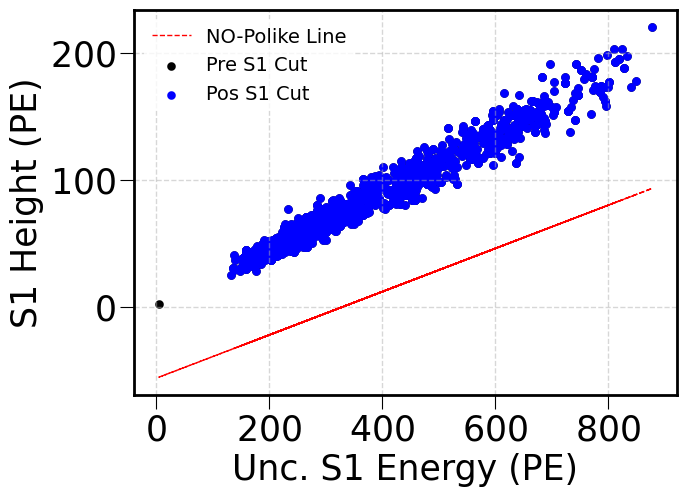

In [19]:
plt.figure(figsize=(7, 5))
plt.scatter(df_doro['S1e'], df_doro['S1h'], alpha=1.0, s=10, c='black', label='Pre S1 Cut')
plt.scatter(S1_doro_df['S1e'], S1_doro_df['S1h'], alpha=1.0, s=10, c='blue', label='Pos S1 Cut')
plt.plot(df_doro['S1e'], M_NOPOLIKE * df_doro['S1e'] + B_NOPOLIKE, c='red', ls='--', lw=1.0, label='NO-Polike Line')
plt.xlabel('Unc. S1 Energy (PE)')
plt.ylabel('S1 Height (PE)')
plt.legend(fontsize=14)
plt.grid(True)
plt.show()

As you can see, the NO-Polike cut is completely unnecesary.
<br>
I will remain it for homogeneization purposes in the data/MC processing.

#### $S1e$ correction

In [20]:
S1_corr_doro_df = crudo.ef.correct_S1e(S1_doro_df, CV_FIT, DT_CATH, output_column='S1e_corr')     # Based on alpha analysis

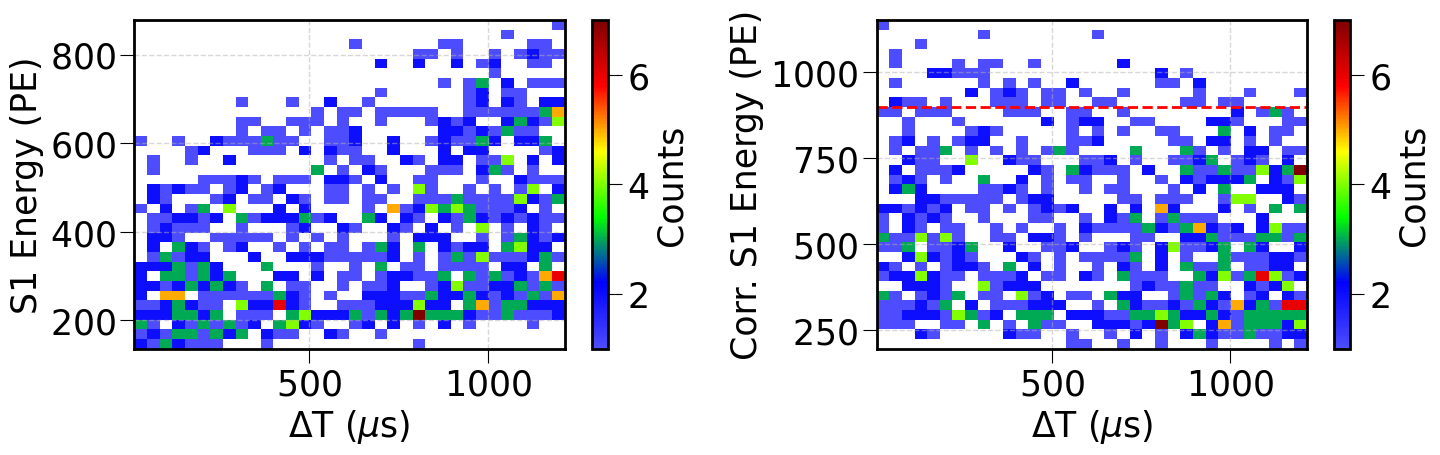

In [21]:
n_bins = 35
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for i, col in enumerate(['S1e', 'S1e_corr']):

    # Variables
    E1 = S1_corr_doro_df[col]
    DT = S1_corr_doro_df['DT']
    R = np.sqrt(S1_corr_doro_df['X']**2 + S1_corr_doro_df['Y']**2)

    # Masking
    rad_mask  = (R  < R_UP)
    time_mask = (DT < 0.9*DT_CATH)
    E1 = E1[rad_mask & time_mask]
    DT = DT[rad_mask & time_mask]

    # 2D histogram
    S1e_DT_map, ex, ey = crudo.pt.hist_2D(DT, E1, x_bins=n_bins, y_bins=n_bins)
    S1e_DT_map = np.ma.masked_where(S1e_DT_map == 0, S1e_DT_map)

    im = axes[i].pcolormesh(ex, ey, S1e_DT_map.T, cmap=crudo.pt.custom_hsv, shading='auto')
    cbar = plt.colorbar(im, ax=axes[i], label='Counts', shrink=1.0)
    axes[i].set_xlabel('$\Delta$T ($\mu$s)')
    axes[i].set_ylabel('Corr. S1 Energy (PE)' if col == 'S1e_corr' else 'S1 Energy (PE)')
    axes[i].grid(True)

    # Possible alpha/electron limit line
    if col == 'S1e_corr':
        axes[i].axhline(y=S1_ENERGY_THRESHOLD, color='red', ls='--')

plt.tight_layout()
plt.show()

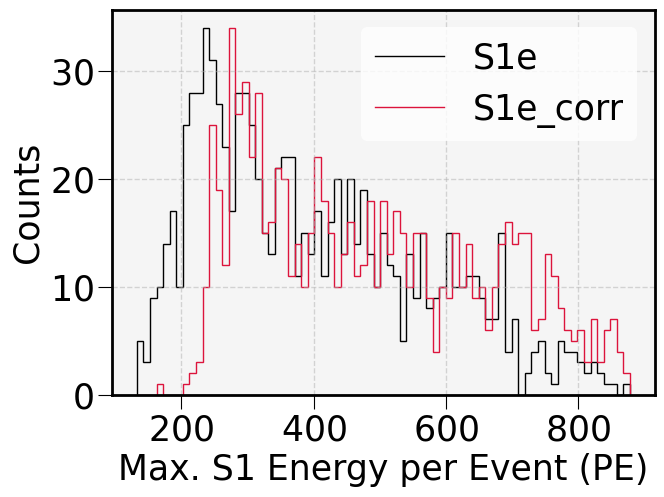

In [22]:
# Global
n_bins = 75
plt.figure(figsize=(7, 5))

# Histogram
data_one_s1  = S1_corr_doro_df[S1_corr_doro_df['nS1'] == 1].copy()
_, s1e_edges = np.histogram(data_one_s1['S1e'], bins=n_bins)

for i, col in enumerate(['S1e', 'S1e_corr']):

    S1e_event = data_one_s1.groupby('event')[col].max()         # Max. S1e per event
    s1e_counts, _ = np.histogram(S1e_event, bins=s1e_edges)

    # Plotting
    plt.stairs(s1e_counts, s1e_edges, label=col,
               fill=False, lw=1.0, ec=crudo.pt.hist_colors[i % len(crudo.pt.hist_colors)])

# Styling
plt.xlabel(f'Max. S1 Energy per Event (PE)')
plt.ylabel('Counts')
plt.legend()
plt.grid(True)
plt.gca().set_facecolor("whitesmoke")
plt.show()

#### Execution

In [23]:
df_doro = S1_corr_doro_df.copy()
df_soph = S1_soph_df.copy()

print(f"After S1 cut & correction: {df_soph['event'].nunique()} events.")

After S1 cut & correction: 953 events.


### NO Spurious Hits

#### Clustering

We first cluster hits in each event using DBSCAN algorithm, tagging -1 hits as noisy hits.

In [24]:
df_clustered = CLUSTER_FUNCTION(df_soph)
df_clustered

,event,time,npeak,Xpeak,X,Y,Z,Q,Ec,cluster
0,3100093,6.200187e+12,0,135.577390,149.925,44.775,1136.497748,5.101449,0.007395,0
1,3100093,6.200187e+12,0,135.577390,134.375,29.225,1139.897164,7.652174,0.001407,0
2,3100093,6.200187e+12,0,135.577390,134.375,44.775,1139.897164,7.130435,0.001308,0
3,3100093,6.200187e+12,0,135.577390,134.375,60.325,1139.897164,14.318841,0.002627,0
4,3100093,6.200187e+12,0,135.577390,134.375,75.875,1139.897164,6.550725,0.001202,0
...,...,...,...,...,...,...,...,...,...,...
416969,171154752,3.423095e+14,0,-234.059591,-250.375,-371.575,1128.166628,10.144928,0.001607,0
416970,171154752,3.423095e+14,0,-234.059591,-235.825,-417.725,1128.166628,8.347826,0.001834,0
416971,171154752,3.423095e+14,0,-234.059591,-235.825,-402.175,1128.166628,5.913043,0.001121,0
416972,171154752,3.423095e+14,0,-234.059591,-235.825,-356.525,1128.166628,5.507246,0.000767,0


Event 501130:


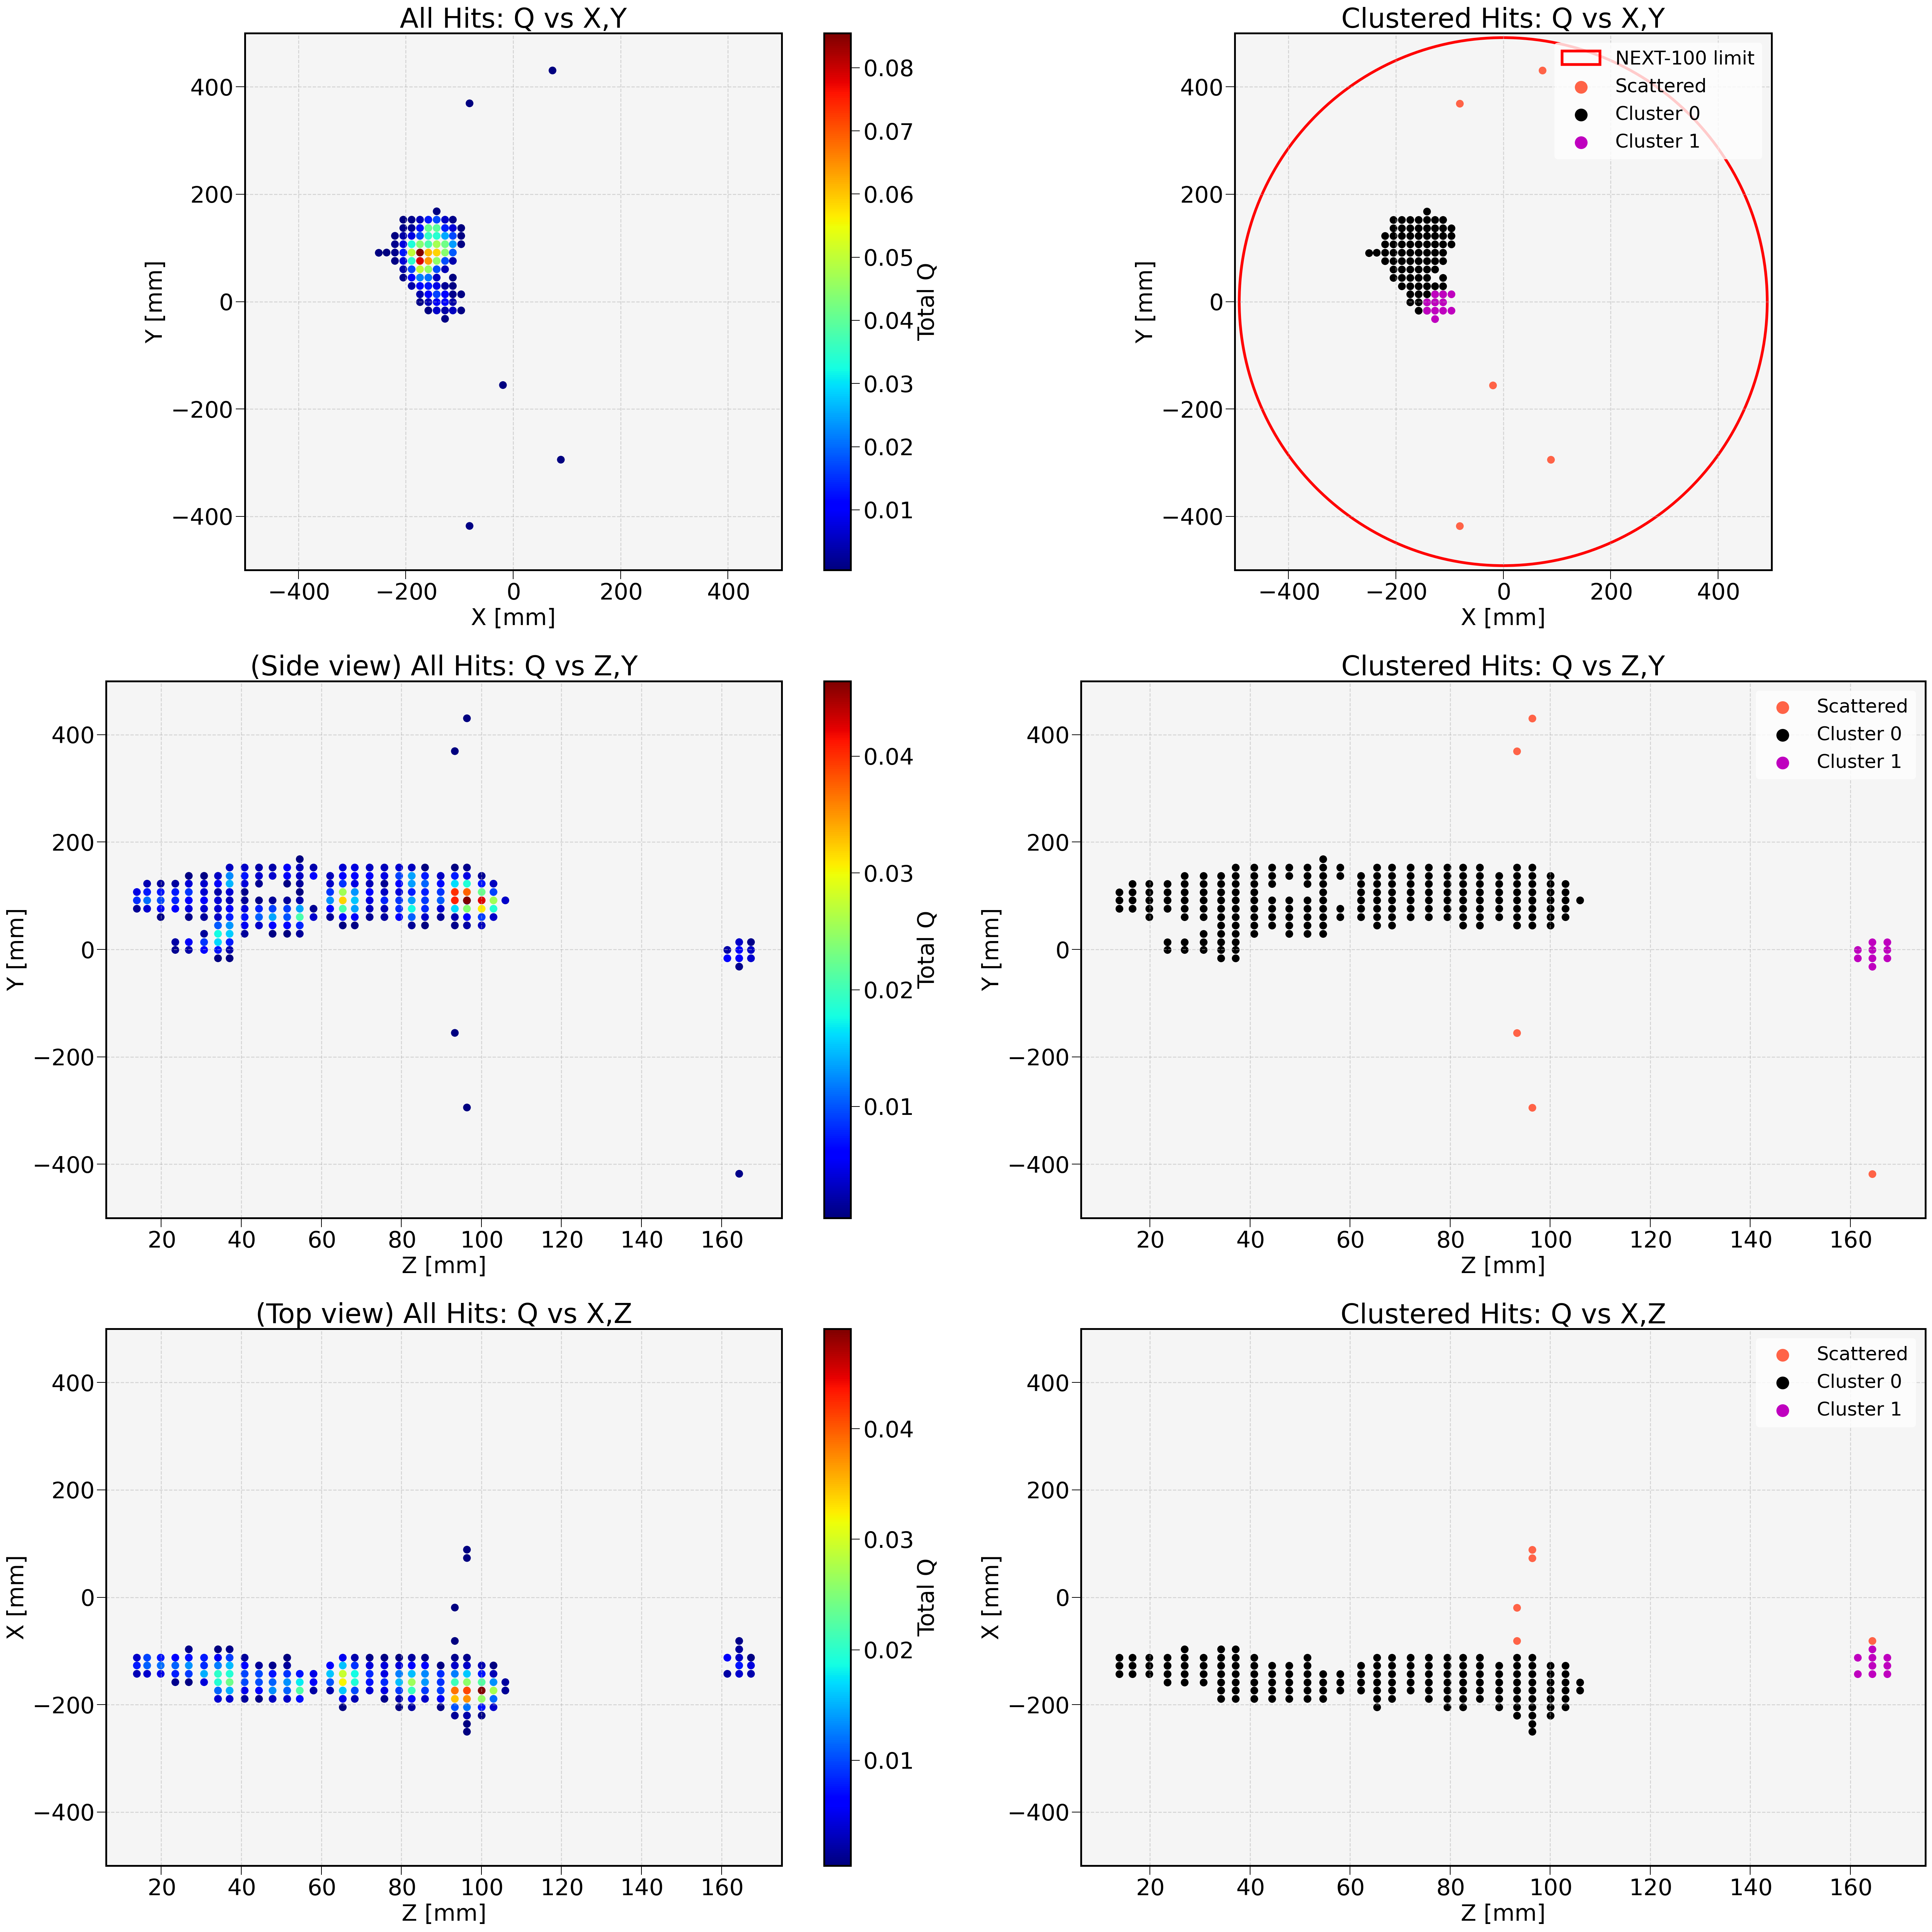

In [25]:
# Pick a random event from the clustered dataframe to visualize its hits
clust_evt_ids = df_clustered['event'].unique()

# Event information + visualization
evt_test_id = np.random.choice(clust_evt_ids)
print(f"Event {evt_test_id}:")
crudo.pt.display_event_cluster(df_clustered, variable='Ec', event=evt_test_id)

#### Energy re-distribution

In [26]:
clean_soph_df = crudo.tf.deal_spurious_hits(df_clustered, energy_column='Ec', output_column='E_hit_mev')
print(f"After cleaning spurious hits: {clean_soph_df['event'].nunique()} events.")

After cleaning spurious hits: 953 events.


Check some event displays!

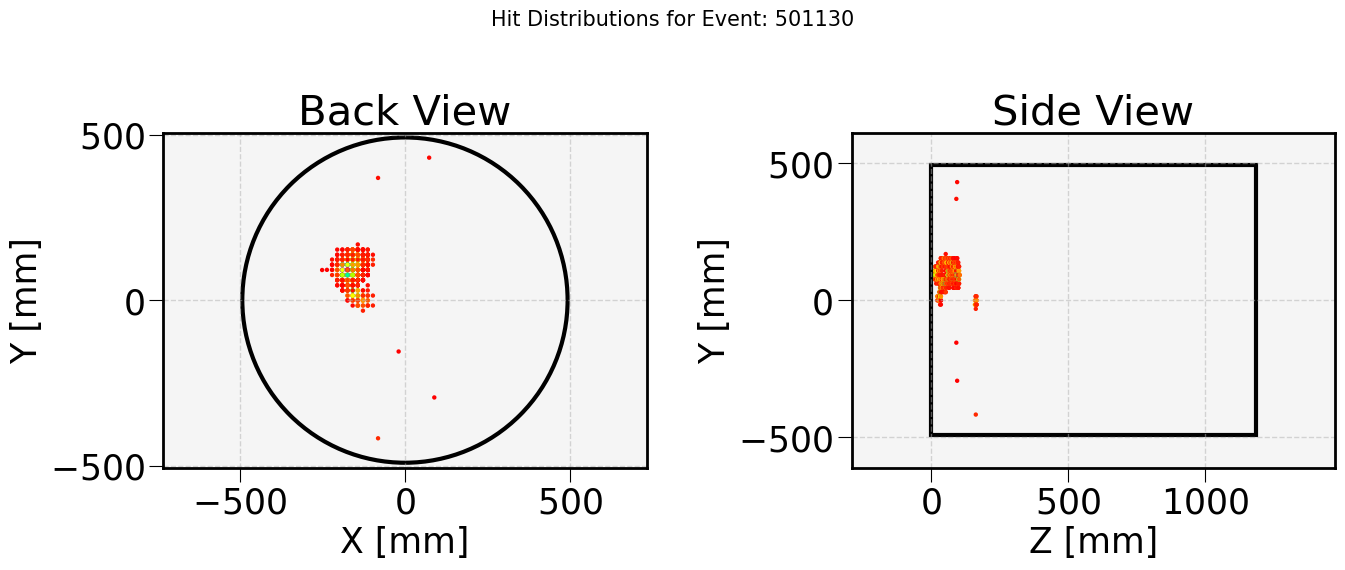

In [27]:
crudo.pt.event_display(df_soph, variable='Ec', event=evt_test_id)

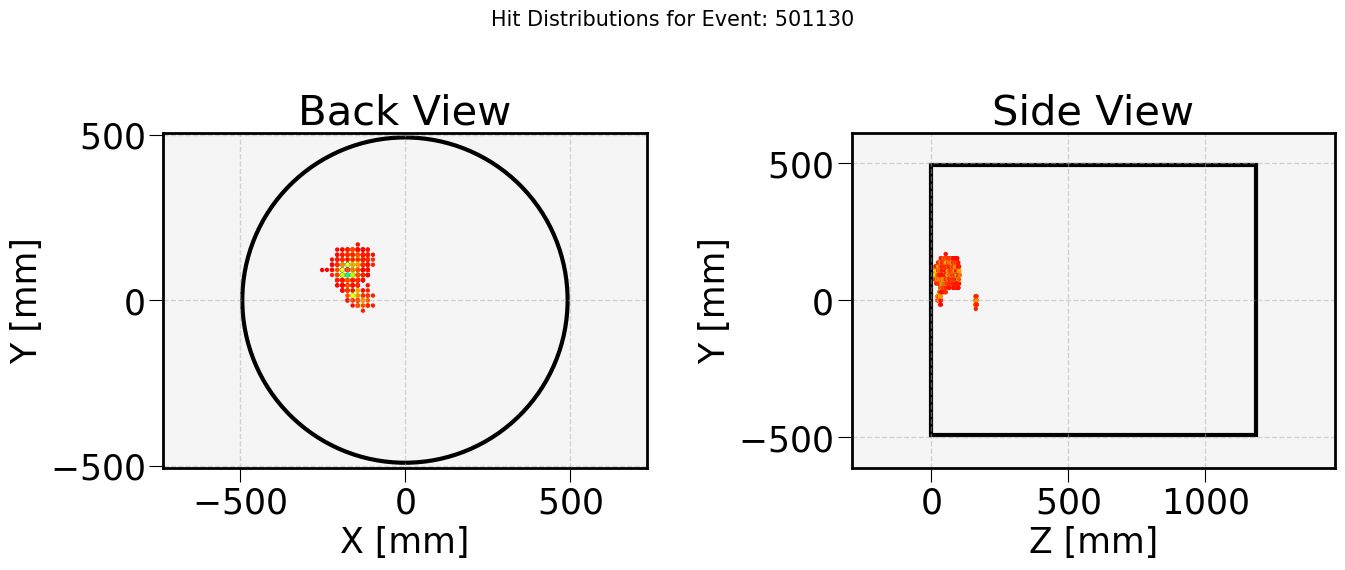

In [28]:
crudo.pt.event_display(clean_soph_df, variable='E_hit_mev', event=evt_test_id)

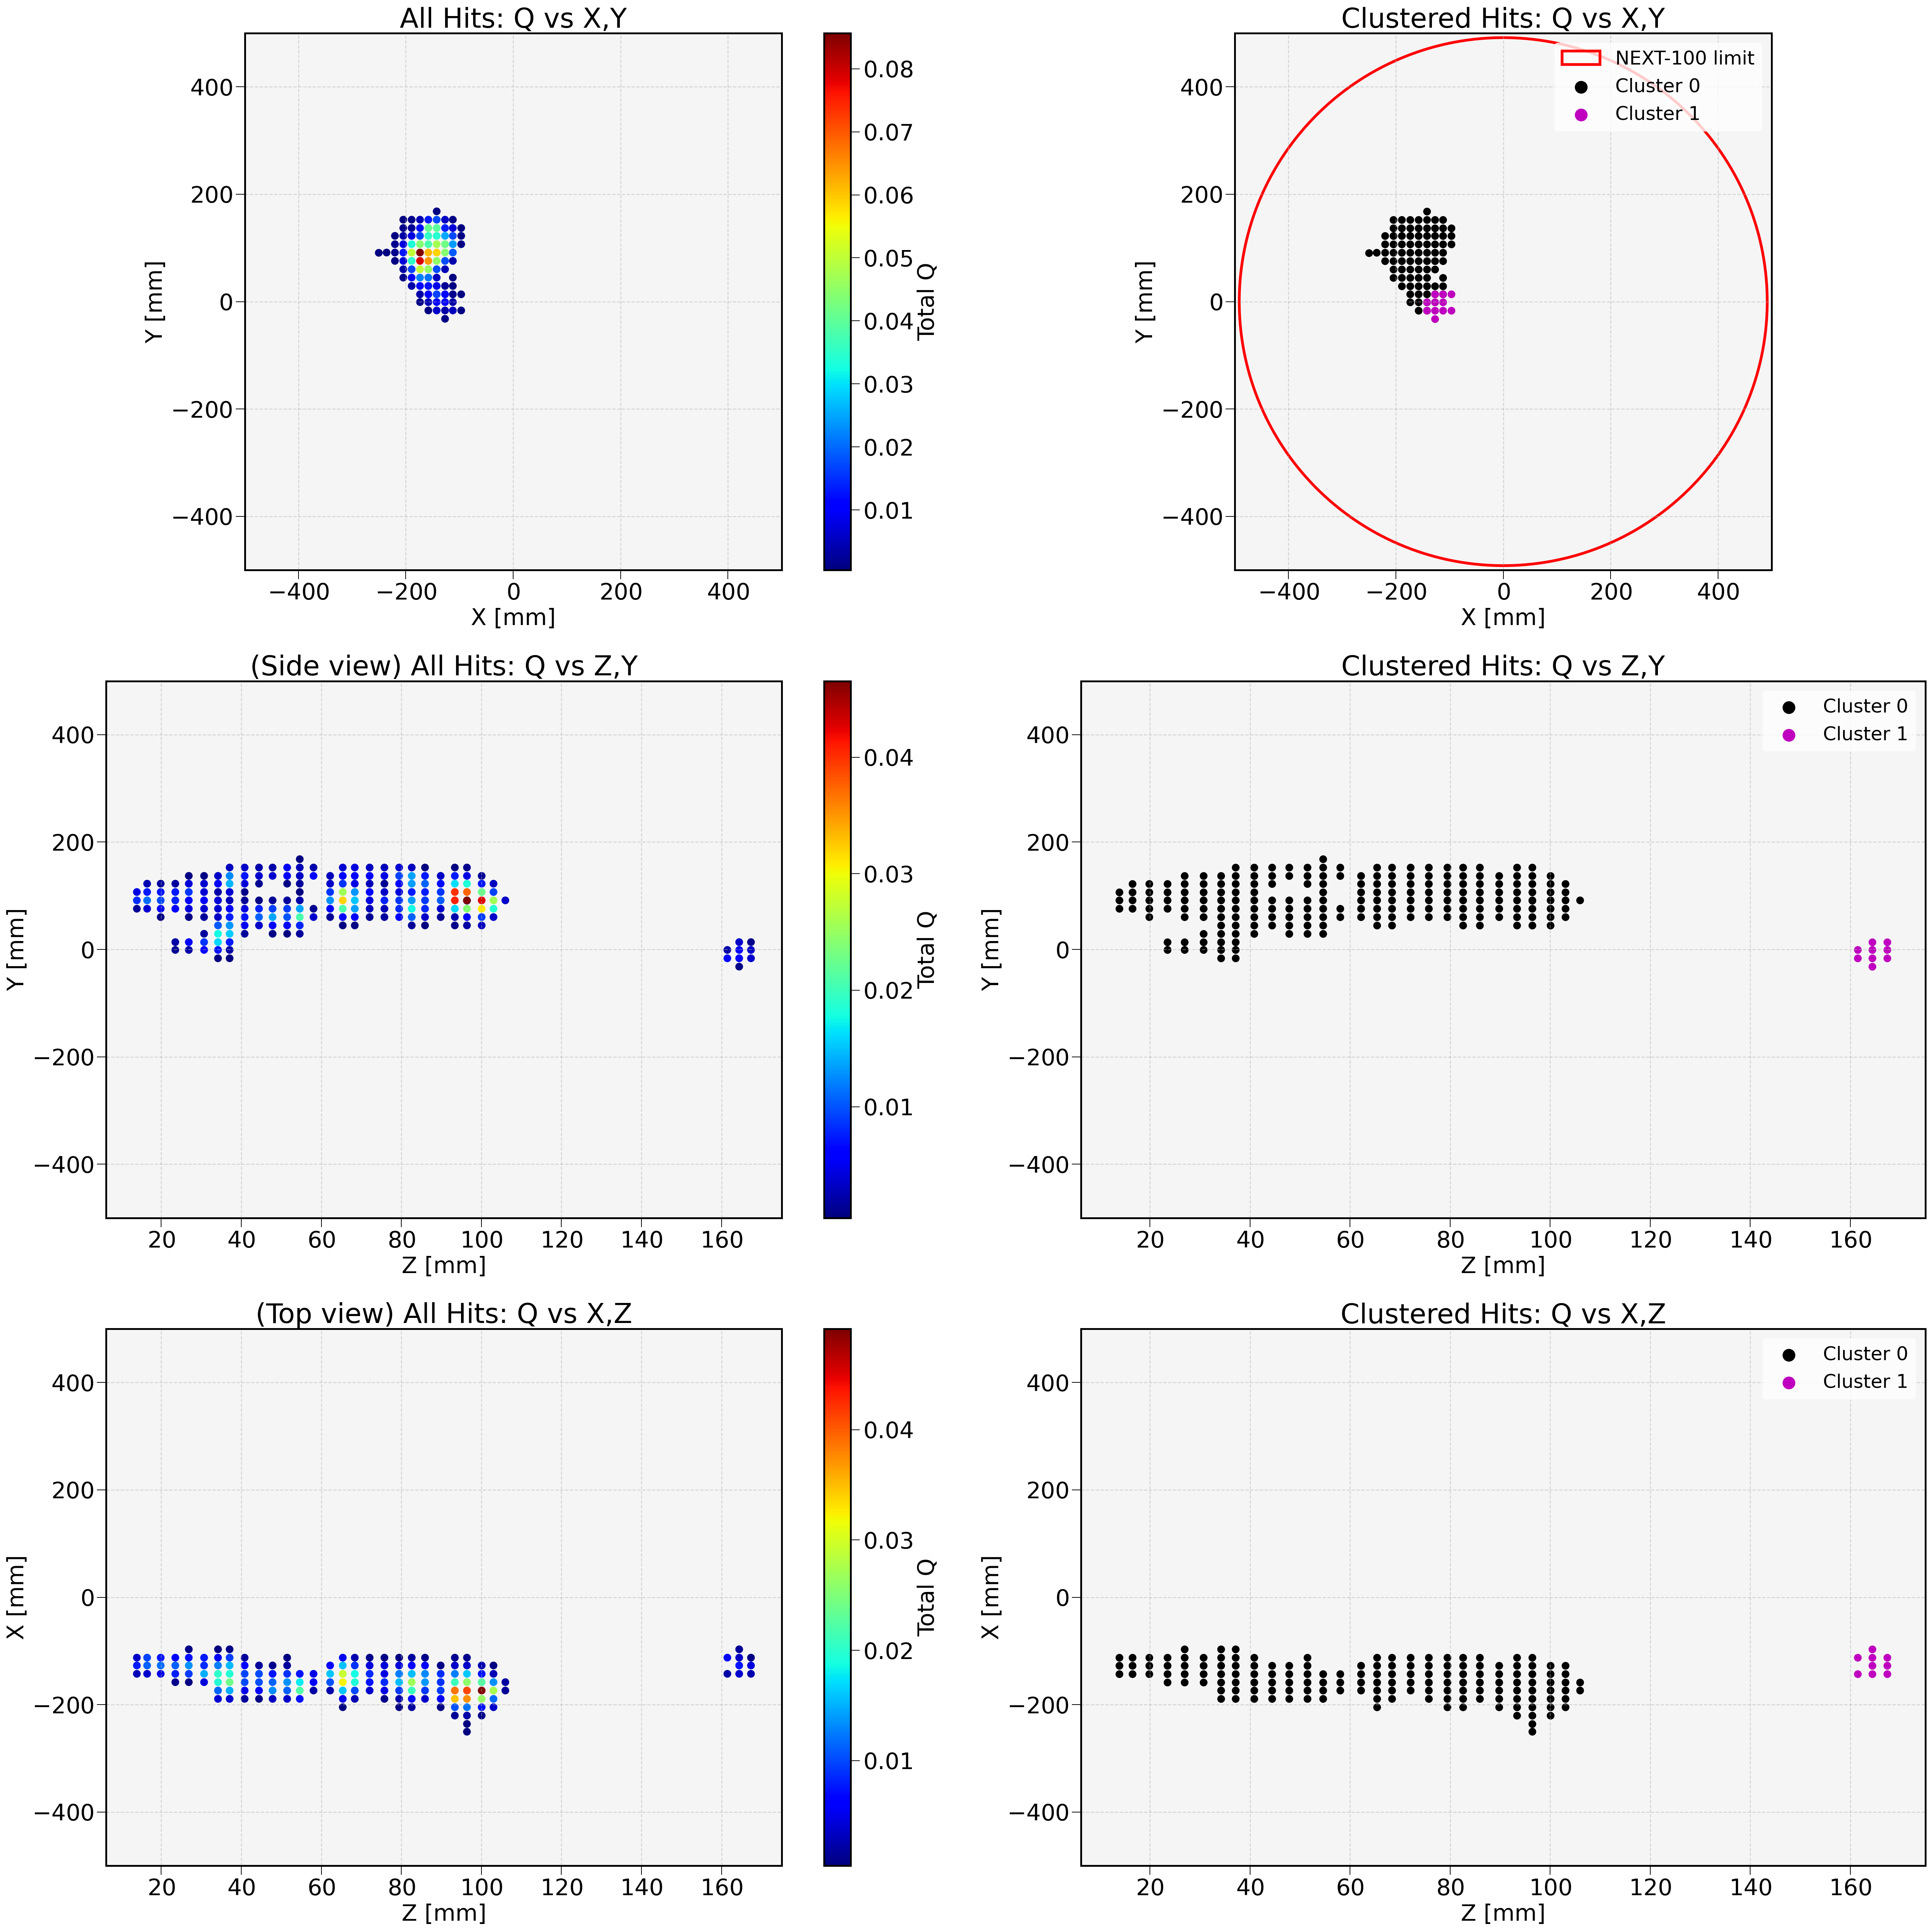

In [29]:
crudo.pt.display_event_cluster(clean_soph_df, variable='E_hit_mev', event=evt_test_id)

#### Update

We do not save the clean dataframe yet, cause' I need old Sophronia dataframe for storage purposes.

In [30]:
after_hits_treatment_ids = clean_soph_df['event'].unique()
df_doro, df_soph = crudo.dm.apply_cut_and_update(df_doro, df_soph, event_ids=after_hits_treatment_ids)
print(f"After dealing with spurious hits: {df_soph['event'].nunique()} events.")

After dealing with spurious hits: 953 events.


In [31]:
clean_soph_df

,event,time,npeak,Xpeak,X,Y,Z,Q,Ec,cluster,E_hit_mev
0,3100093,6.200187e+12,0,135.577390,149.925,44.775,1136.497748,5.101449,0.007395,0,0.007406
1,3100093,6.200187e+12,0,135.577390,134.375,29.225,1139.897164,7.652174,0.001407,0,0.001409
2,3100093,6.200187e+12,0,135.577390,134.375,44.775,1139.897164,7.130435,0.001308,0,0.001310
3,3100093,6.200187e+12,0,135.577390,134.375,60.325,1139.897164,14.318841,0.002627,0,0.002631
4,3100093,6.200187e+12,0,135.577390,134.375,75.875,1139.897164,6.550725,0.001202,0,0.001203
...,...,...,...,...,...,...,...,...,...,...,...
415322,171154752,3.423095e+14,0,-234.059591,-250.375,-371.575,1128.166628,10.144928,0.001607,0,0.001609
415323,171154752,3.423095e+14,0,-234.059591,-235.825,-417.725,1128.166628,8.347826,0.001834,0,0.001835
415324,171154752,3.423095e+14,0,-234.059591,-235.825,-402.175,1128.166628,5.913043,0.001121,0,0.001122
415325,171154752,3.423095e+14,0,-234.059591,-235.825,-356.525,1128.166628,5.507246,0.000767,0,0.000767


### Data @ Event/Peak-level

#### From Dorothea & old Sophronia

In [32]:
original_evt_size_df = df_soph.groupby('event').size().rename('old_n_hits').reset_index()
df_doro = df_doro.merge(original_evt_size_df, on='event', how='left')

In [36]:
# df_doro.event.nunique()
df_doro

,event,time,nS1,nS2,S1w,S1h,S1e,S1t,S2w,S2h,...,S2t,DT,X,Y,Z,volume,isotope,double_e,S1e_corr,old_n_hits
0,3100093,6.200187e+12,1,1,650.0,61.0,256.0,10000.0,75.250,7532.0,...,1.340487e+06,1330.487427,135.577389,57.063271,1157.524048,PMT,K40,False,257.831153,270
1,3100094,6.200188e+12,1,1,650.0,181.0,723.0,10000.0,253.475,12938.0,...,9.484850e+05,938.485046,-200.397178,172.446104,816.481934,PMT,K40,False,850.370407,800
2,3100095,6.200191e+12,1,1,575.0,127.0,611.0,10000.0,123.600,14642.0,...,7.534885e+05,743.488525,-103.532961,54.520847,646.834961,PMT,K40,False,784.093957,727
3,3100096,6.200192e+12,1,1,550.0,75.0,377.0,10000.0,153.900,3887.0,...,1.127490e+06,1117.489746,345.982319,-217.956477,972.216064,PMT,K40,False,411.854662,451
4,3100097,6.200194e+12,1,3,450.0,50.0,234.0,10000.0,35.325,5307.0,...,2.434883e+05,233.488297,185.970528,-436.071377,203.134796,PMT,K40,False,394.195132,254
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1250,429296568,8.585931e+14,1,2,600.0,58.0,256.0,10000.0,54.525,6017.0,...,8.574814e+05,847.481445,-39.479894,455.593976,737.308777,VESSEL,K40,False,313.305273,214
1251,429296569,8.585931e+14,1,1,475.0,48.0,207.0,10000.0,89.975,2761.0,...,8.574868e+05,847.486877,374.512876,251.958027,737.313538,VESSEL,K40,False,253.336072,228
1252,429296570,8.585931e+14,1,1,550.0,149.0,649.0,10000.0,203.025,9256.0,...,1.214487e+06,1204.487427,-311.104448,53.378277,1047.904053,VESSEL,K40,False,685.295535,646
1253,429296571,8.585931e+14,1,1,500.0,53.0,213.0,10000.0,92.150,4444.0,...,9.394815e+05,929.481567,-407.972843,-26.288965,808.648865,VESSEL,K40,False,251.493414,306


In [47]:
doro_info_df = crudo.dm.summarize_dorothea_info(df_doro, event_level_cols=EVENT_LEVEL_COLS)
doro_info_df

,event,nS1,nS2,isotope,volume,double_e,old_n_hits,time,S1e,S1e_corr,S1w,S1h,S1t,S2e,S2w,S2h,S2t,S2q
0,500445,1,1,K40,SIPM_BOARD,False,343,1.000891e+12,291.0,331.754267,550.0,73.0,10000.0,181313.0,75.300,6757.0,1.022494e+06,6197.970703
1,500449,0,2,K40,SIPM_BOARD,False,44,1.000899e+12,NaN,NaN,NaN,NaN,NaN,21753.0,12.600,5169.0,6.449774e+04,613.043457
2,500449,0,2,K40,SIPM_BOARD,False,44,1.000899e+12,NaN,NaN,NaN,NaN,NaN,10831.0,12.850,2041.0,9.748236e+04,236.463745
3,500450,1,2,K40,SIPM_BOARD,False,290,1.000900e+12,239.0,378.921032,550.0,59.0,10000.0,111569.0,33.100,11029.0,3.454826e+05,3179.768066
4,500450,1,2,K40,SIPM_BOARD,False,290,1.000900e+12,239.0,303.448619,550.0,59.0,10000.0,121430.0,43.150,8255.0,7.764828e+05,3525.970947
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1250,4009755391,1,1,K40,VESSEL,False,292,8.019511e+15,261.0,264.417951,650.0,62.0,10000.0,177868.0,91.325,5509.0,1.324486e+06,4957.854980
1251,4009755392,1,1,K40,VESSEL,False,225,8.019511e+15,245.0,286.322986,475.0,51.0,10000.0,163407.0,75.575,8095.0,9.634839e+05,4725.391113
1252,4009755393,1,2,K40,VESSEL,False,452,8.019511e+15,389.0,437.309824,475.0,98.0,10000.0,200919.0,76.650,7028.0,1.056491e+06,6010.028320
1253,4009755393,1,2,K40,VESSEL,False,452,8.019511e+15,389.0,392.645534,475.0,98.0,10000.0,95069.0,57.175,4810.0,1.334491e+06,2449.739014


In [48]:
doro_info_df.nunique()

event          953
nS1              2
nS2              4
isotope          1
volume           7
double_e         2
old_n_hits     532
time           953
S1e            451
S1e_corr      1219
S1w             21
S1h            163
S1t              3
S2e           1248
S2w           1126
S2h           1199
S2t           1254
S2q           1253
dtype: int64

#### From Sophronia (NO spurious hits)

In [38]:
clean_soph_df

,event,time,npeak,Xpeak,X,Y,Z,Q,Ec,cluster,E_hit_mev
0,3100093,6.200187e+12,0,135.577390,149.925,44.775,1136.497748,5.101449,0.007395,0,0.007406
1,3100093,6.200187e+12,0,135.577390,134.375,29.225,1139.897164,7.652174,0.001407,0,0.001409
2,3100093,6.200187e+12,0,135.577390,134.375,44.775,1139.897164,7.130435,0.001308,0,0.001310
3,3100093,6.200187e+12,0,135.577390,134.375,60.325,1139.897164,14.318841,0.002627,0,0.002631
4,3100093,6.200187e+12,0,135.577390,134.375,75.875,1139.897164,6.550725,0.001202,0,0.001203
...,...,...,...,...,...,...,...,...,...,...,...
415322,171154752,3.423095e+14,0,-234.059591,-250.375,-371.575,1128.166628,10.144928,0.001607,0,0.001609
415323,171154752,3.423095e+14,0,-234.059591,-235.825,-417.725,1128.166628,8.347826,0.001834,0,0.001835
415324,171154752,3.423095e+14,0,-234.059591,-235.825,-402.175,1128.166628,5.913043,0.001121,0,0.001122
415325,171154752,3.423095e+14,0,-234.059591,-235.825,-356.525,1128.166628,5.507246,0.000767,0,0.000767


In [49]:
df_final_soph = clean_soph_df.loc[:, FINAL_SOPH_COLUMNS].copy()
df_final_soph

,event,time,npeak,X,Y,Z,E_hit_mev,cluster
0,3100093,6.200187e+12,0,149.925,44.775,1136.497748,0.007406,0
1,3100093,6.200187e+12,0,134.375,29.225,1139.897164,0.001409,0
2,3100093,6.200187e+12,0,134.375,44.775,1139.897164,0.001310,0
3,3100093,6.200187e+12,0,134.375,60.325,1139.897164,0.002631,0
4,3100093,6.200187e+12,0,134.375,75.875,1139.897164,0.001203,0
...,...,...,...,...,...,...,...,...
415322,171154752,3.423095e+14,0,-250.375,-371.575,1128.166628,0.001609,0
415323,171154752,3.423095e+14,0,-235.825,-417.725,1128.166628,0.001835,0
415324,171154752,3.423095e+14,0,-235.825,-402.175,1128.166628,0.001122,0
415325,171154752,3.423095e+14,0,-235.825,-356.525,1128.166628,0.000767,0


In [50]:
soph_event_info_df = crudo.dm.summarize_hits_to_event_level(df_final_soph)
soph_event_info_df

,event,E_evt_mev,n_cluster,n_hits,X_bary,Y_bary,Z_bary,X_min,X_max,Y_min,Y_max,Z_min,Z_max,R_max
0,500445,0.584316,1,342,-29.799443,446.727978,887.868545,-96.875,42.075,338.225,492.725,867.714510,915.822900,497.095842
1,500449,0.086682,2,44,294.088429,289.406024,14.932566,257.775,335.525,245.425,337.725,4.883341,35.303863,444.842479
2,500450,0.573516,2,288,-69.424895,-36.191811,489.242305,-235.825,104.275,-155.375,75.875,281.805561,678.187511,260.101915
3,500452,0.030628,1,14,175.819209,195.169210,4.337272,149.925,196.575,168.175,214.825,2.070498,6.699133,280.926736
4,500464,0.894085,1,402,-143.865593,-159.055712,132.413262,-204.725,-96.875,-217.575,-109.725,40.217388,174.844879,276.769365
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
948,4009755390,0.930351,1,582,-79.144030,-434.356555,977.203064,-189.175,-3.575,-479.925,-371.075,920.828445,1031.631862,496.437968
949,4009755391,0.444670,1,289,-170.335597,-14.451486,1136.852323,-235.825,-112.425,-63.075,44.775,1107.711731,1155.993904,240.566116
950,4009755392,0.424492,1,225,127.240430,291.988192,827.506528,73.175,181.025,230.375,338.225,807.583862,845.600578,369.964399
951,4009755393,0.748372,2,450,140.663955,166.047456,984.412697,73.175,212.125,13.675,276.025,879.894401,1168.108001,321.825692


In [51]:
# soph_peak_info_df = df_final_soph.groupby(['event', 'npeak']).agg(E_peak_mev=('E_hit_mev', 'sum')).reset_index()
# soph_peak_info_df

#### Aggregate

In [52]:
# df_file = pd.merge(soph_peak_info_df, soph_event_info_df, on='event', how='left')
df_file = pd.merge(doro_info_df, soph_event_info_df, on='event', how='left')
df_file

,event,nS1,nS2,isotope,volume,double_e,old_n_hits,time,S1e,S1e_corr,...,X_bary,Y_bary,Z_bary,X_min,X_max,Y_min,Y_max,Z_min,Z_max,R_max
0,500445,1,1,K40,SIPM_BOARD,False,343,1.000891e+12,291.0,331.754267,...,-29.799443,446.727978,887.868545,-96.875,42.075,338.225,492.725,867.714510,915.822900,497.095842
1,500449,0,2,K40,SIPM_BOARD,False,44,1.000899e+12,NaN,NaN,...,294.088429,289.406024,14.932566,257.775,335.525,245.425,337.725,4.883341,35.303863,444.842479
2,500449,0,2,K40,SIPM_BOARD,False,44,1.000899e+12,NaN,NaN,...,294.088429,289.406024,14.932566,257.775,335.525,245.425,337.725,4.883341,35.303863,444.842479
3,500450,1,2,K40,SIPM_BOARD,False,290,1.000900e+12,239.0,378.921032,...,-69.424895,-36.191811,489.242305,-235.825,104.275,-155.375,75.875,281.805561,678.187511,260.101915
4,500450,1,2,K40,SIPM_BOARD,False,290,1.000900e+12,239.0,303.448619,...,-69.424895,-36.191811,489.242305,-235.825,104.275,-155.375,75.875,281.805561,678.187511,260.101915
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1250,4009755391,1,1,K40,VESSEL,False,292,8.019511e+15,261.0,264.417951,...,-170.335597,-14.451486,1136.852323,-235.825,-112.425,-63.075,44.775,1107.711731,1155.993904,240.566116
1251,4009755392,1,1,K40,VESSEL,False,225,8.019511e+15,245.0,286.322986,...,127.240430,291.988192,827.506528,73.175,181.025,230.375,338.225,807.583862,845.600578,369.964399
1252,4009755393,1,2,K40,VESSEL,False,452,8.019511e+15,389.0,437.309824,...,140.663955,166.047456,984.412697,73.175,212.125,13.675,276.025,879.894401,1168.108001,321.825692
1253,4009755393,1,2,K40,VESSEL,False,452,8.019511e+15,389.0,392.645534,...,140.663955,166.047456,984.412697,73.175,212.125,13.675,276.025,879.894401,1168.108001,321.825692
